# Setup python environment

In [1]:
%pip install pandas numpy matplotlib tensorflow scikit-learn ai_edge_litert

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import tensorflow as tf
import random
import os

# Set the seed for reproducibility
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)


# Constants

In [3]:
FEATURE_COLS = [
    "temperature",
    "pressure",
    "humidity",
    "gas_resistance",
]
FEATURE_COLS_EXTENDED = FEATURE_COLS + ["gas_resistance_diff",]
TARGET_COL = "label"
SEQ_LEN = 3

CLASSES = [
    "air",
    "basil",
    "cinnamon",
    "oregano",
    "rosemary"
]

NUM_CLASSES = len(CLASSES)

# Load Data

In [4]:
import os
import pandas as pd

def add_fotd_features(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    df = df.copy()
    
    # Ensure correct order
    df = df.sort_values(["id", "position"])
    
    for col in feature_cols:
        df[col + "_diff"] = df.groupby("id")[col].diff()
    
    df = df.fillna(0)
    return df


def load_dataset(base_dir: str) -> pd.DataFrame:
    dfs = []
    i = 0
    for folder in os.listdir(base_dir):
        if folder not in CLASSES:
            continue

        folder_path = os.path.join(base_dir, folder)
        if not os.path.isdir(folder_path):
            continue

        for file in os.listdir(folder_path):
            if not file.endswith(".csv"):
                continue

            file_path = os.path.join(folder_path, file)
            df = pd.read_csv(file_path)

            # Filter to positions 1, 2, 3
            df = df[df['position'].isin([1,2,3])].copy()

            df['id'] = df.apply(lambda x: f"{i}_{x['sensor_index']}_{x['fingerprint_index']}", axis=1)
            if file.endswith("open_room.csv"): df["environment"] = "open"
            if file.endswith("closed_container.csv"): df["environment"] = "closed"
            i += 1
            dfs.append(df)

    if len(dfs) == 0:
        raise ValueError(f"No CSVs found under {base_dir}")
    return pd.concat(dfs, ignore_index=True)



data = load_dataset("../data/dataset")
data = add_fotd_features(data, ["gas_resistance"])
print(len(data["id"].unique()), " fingerprints loaded.")
data.head(50)

11100  fingerprints loaded.


,sensor_index,fingerprint_index,position,plate_temperature,heater_duration,temperature,pressure,humidity,gas_resistance,label,id,environment,gas_resistance_diff
0,1,0,1,100,150,24.39,1022.75,46.61,414156,air,0_1_0,closed,0.0
8,1,0,2,100,150,24.44,1022.75,46.50,430886,air,0_1_0,closed,16730.0
23,1,1,1,100,150,24.79,1022.76,45.18,247283,air,0_1_1,closed,0.0
31,1,1,2,100,150,24.82,1022.75,45.07,262295,air,0_1_1,closed,15012.0
39,1,1,3,100,150,24.84,1022.75,45.04,277883,air,0_1_1,closed,15588.0
225,1,10,1,100,150,26.18,1022.79,41.38,4694556,air,0_1_10,closed,0.0
227,1,10,2,100,150,26.16,1022.80,41.34,4406671,air,0_1_10,closed,-287885.0
228,1,10,3,100,150,26.14,1022.81,41.28,3734671,air,0_1_10,closed,-672000.0
2231,1,100,1,100,150,31.01,1023.13,32.76,7013699,air,0_1_100,closed,0.0
2232,1,100,2,100,150,30.99,1023.13,32.77,6187311,air,0_1_100,closed,-826388.0


Drop incomplete fingerprints.

In [5]:
complete_ids = []
grouped = data.groupby("id")
for group in grouped:
    seq_len = len(group[1])
    if seq_len == SEQ_LEN:
        complete_ids.append(group[0])

data = data[data["id"].isin(complete_ids)]
print("Number of complete fingerprints per class: ")
for cls in CLASSES:
    print(
        f"{cls+' '*(max(map(len, CLASSES)) - len(cls))}\t{len(data[data[TARGET_COL] == cls]["id"].unique())}"
    )

Number of complete fingerprints per class: 
air     	1748
basil   	1739
cinnamon	1736
oregano 	1738
rosemary	1765


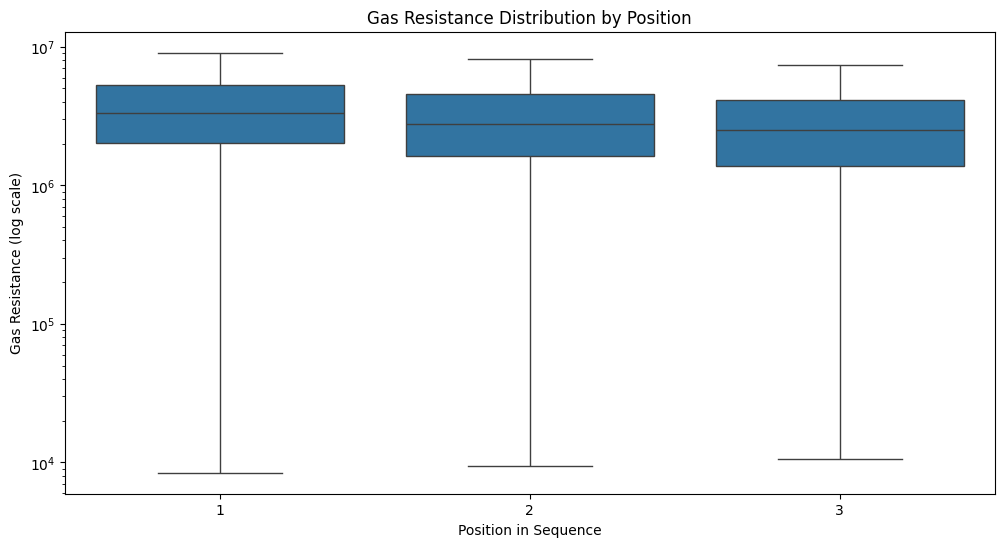

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot first few timesteps to see warmup on a log scale
plt.figure(figsize=(12,6))
sns.boxplot(x='position', y='gas_resistance', data=data)
plt.title("Gas Resistance Distribution by Position")
plt.xlabel("Position in Sequence")
plt.ylabel("Gas Resistance (log scale)")
plt.yscale('log')  # Set logarithmic scale for y-axis
plt.show()

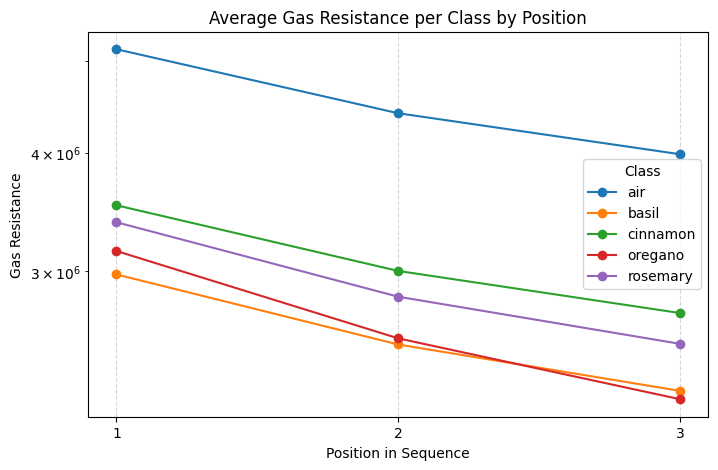

In [7]:
import matplotlib.pyplot as plt

# Compute average gas_resistance per class per position
avg_gas = data.groupby(['label', 'position'])['gas_resistance'].mean().unstack(level=0)

plt.figure(figsize=(8,5))

for cls in avg_gas.columns:
    plt.plot(avg_gas.index, avg_gas[cls], marker='o', label=cls)

plt.title("Average Gas Resistance per Class by Position")
plt.xlabel("Position in Sequence")
plt.ylabel("Gas Resistance")
plt.yscale('log')  # optional: use log scale if values vary a lot
plt.xticks(avg_gas.index)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Class")
plt.show()

## Split Data

This has to happen at this stage to prevent data leakage.

For the final version that gets exported, use all the available data, but we need train-test split for in-place evaluation.

In [8]:
TEST_RATIO = 0.5
train_data_ids = np.random.choice(complete_ids, size=int(len(complete_ids)*(1 - TEST_RATIO)), replace=False)
train_data = data[data["id"].isin(train_data_ids)]
test_data = data[data["id"].isin([i for i in complete_ids if i not in train_data_ids])]

print("Number of training fingerprints: ",len(train_data["id"].unique()))
print("Number of testing fingerprints: ", len(test_data["id"].unique()))


# TEST_OPEN_RATIO = 0.7  # % of open data used for testing

# # --- Separate IDs by environment ---
# closed_ids = data[data["environment"] == "closed"]["id"].unique()
# open_ids   = data[data["environment"] == "open"]["id"].unique()

# # --- Sample open IDs ---
# np.random.seed(42)
# n_open_test = int(len(open_ids) * TEST_OPEN_RATIO)

# open_test_ids  = np.random.choice(open_ids, size=n_open_test, replace=False)
# open_train_ids = np.array([i for i in open_ids if i not in open_test_ids])

# # --- Final splits ---
# train_ids = np.concatenate([closed_ids, open_train_ids])
# test_ids  = open_test_ids

# train_data = data[data["id"].isin(train_ids)]
# test_data  = data[data["id"].isin(test_ids)]

# print("Training fingerprints:")
# print("  closed:", len(closed_ids))
# print("  open  :", len(open_train_ids))
# print("  total :", len(train_data["id"].unique()))

# print("\nTesting fingerprints (open only):", len(test_data["id"].unique()))

Number of training fingerprints:  4363
Number of testing fingerprints:  4363


# Neural Network

## Data preprocessing

In [9]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- Encode labels ---
label_encoder = LabelEncoder()
train_data['label_enc'] = label_encoder.fit_transform(train_data[TARGET_COL])
test_data['label_enc'] = label_encoder.transform(test_data[TARGET_COL])

# --- Copy datasets ---
train_data_scaled = train_data.copy()
test_data_scaled = test_data.copy()

scaler = StandardScaler()
train_data_scaled[FEATURE_COLS_EXTENDED] = scaler.fit_transform(train_data[FEATURE_COLS_EXTENDED])
test_data_scaled[FEATURE_COLS_EXTENDED] = scaler.transform(test_data[FEATURE_COLS_EXTENDED])

In [10]:
import numpy as np

def create_sequences_grouped(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
    seq_len: int
):
    X, y = [], []
    grouped = df.groupby("id")
    num_skipped = 0
    for _id, group in grouped:
        group = group.sort_values("position")
        data = group[feature_cols].values

        if len(data) == seq_len:
            X.append(data)
            y.append(int(group[target_col].iloc[0]))
        else:
            num_skipped += 1
    print("Number of sequences skipped: ", num_skipped)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)


X_train_seq, y_train_seq = create_sequences_grouped(train_data_scaled, FEATURE_COLS_EXTENDED, 'label_enc', SEQ_LEN)
X_test_seq, y_test_seq = create_sequences_grouped(test_data_scaled, FEATURE_COLS_EXTENDED, 'label_enc', SEQ_LEN)

Number of sequences skipped:  0
Number of sequences skipped:  0


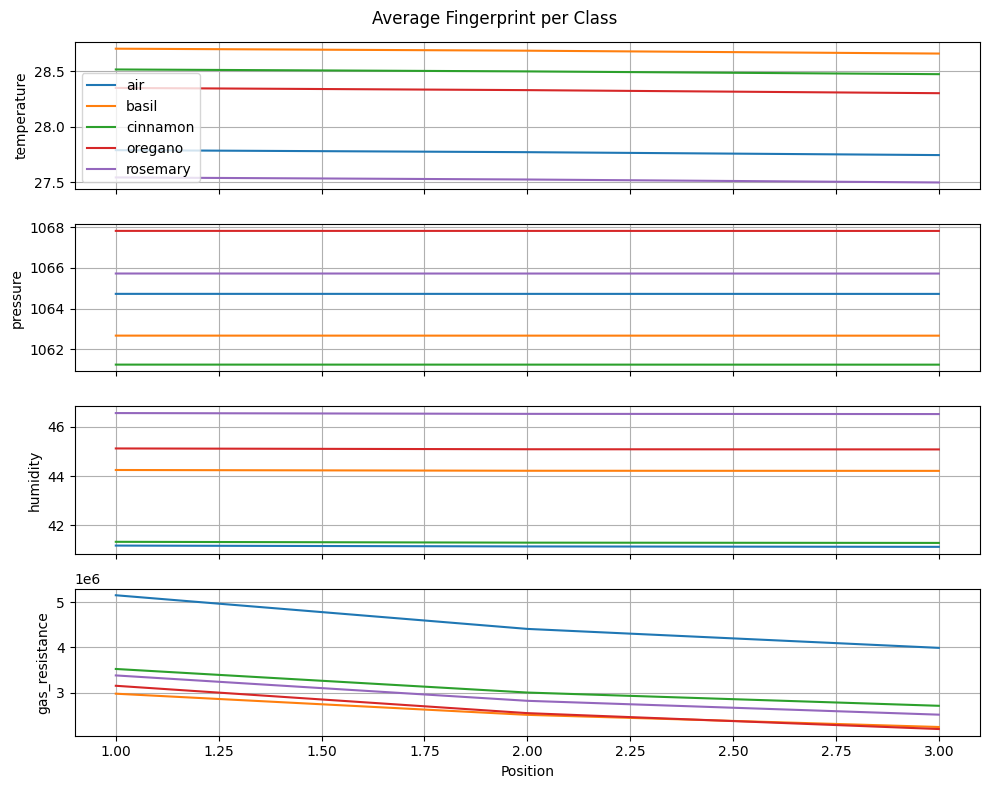

In [11]:
import matplotlib.pyplot as plt

SAMPLES_PER_CLASS = 3

avg_curves = {}

for cls in CLASSES:
    class_df = data[data[TARGET_COL] == cls]

    # Group by position (0 → SEQ_LEN-1) and average
    grouped = class_df.groupby("position")[FEATURE_COLS].mean()

    avg_curves[cls] = grouped

fig, axes = plt.subplots(len(FEATURE_COLS), 1, figsize=(10, 8), sharex=True)

for i, feat in enumerate(FEATURE_COLS):
    for cls in CLASSES:
        axes[i].plot(
            avg_curves[cls].index,
            avg_curves[cls][feat],
            label=cls
        )

    axes[i].set_ylabel(feat)
    axes[i].grid(True)

axes[-1].set_xlabel("Position")
axes[0].legend()
fig.suptitle("Average Fingerprint per Class")

plt.tight_layout()
plt.show()

## Build model

In [12]:
from keras.models import Sequential
from keras.layers import Conv1D, Dense, Dropout, Input, GlobalAveragePooling1D

model = Sequential([
    Input(shape=(SEQ_LEN, len(FEATURE_COLS_EXTENDED))),

    Conv1D(32, kernel_size=2, activation='relu'),
    Conv1D(32, kernel_size=2, activation='relu'),

    GlobalAveragePooling1D(),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2, 32)          │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1, 32)          │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,869 (19.02 KB)

 Trainable params: 4,869 (19.02 KB)

 Non-trainable params: 0 (0.00 B)

## Train model

In [13]:
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split


early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


X_train_seq, X_val_seq, y_train_seq, y_val_seq = train_test_split(
    X_train_seq,
    y_train_seq,
    test_size=0.1,
    stratify=y_train_seq,
    random_state=42
)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop],
    shuffle=True
)

Epoch 1/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3026 - loss: 1.5526 - val_accuracy: 0.3638 - val_loss: 1.4438
Epoch 2/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3818 - loss: 1.4002 - val_accuracy: 0.4096 - val_loss: 1.3251
Epoch 3/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4302 - loss: 1.2917 - val_accuracy: 0.4325 - val_loss: 1.2631
Epoch 4/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4636 - loss: 1.2255 - val_accuracy: 0.4783 - val_loss: 1.2148
Epoch 5/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4931 - loss: 1.1691 - val_accuracy: 0.5034 - val_loss: 1.1541
Epoch 6/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5285 - loss: 1.1130 - val_accuracy: 0.5378 - val_loss: 1.0937
Epoch 7/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5596 - loss: 1.0569 - val_accuracy: 0.5584 - val_loss: 1.0455
Epoch 8/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5810 - loss: 1.0127 - val_accuracy: 0.5881 - v

## Graph training

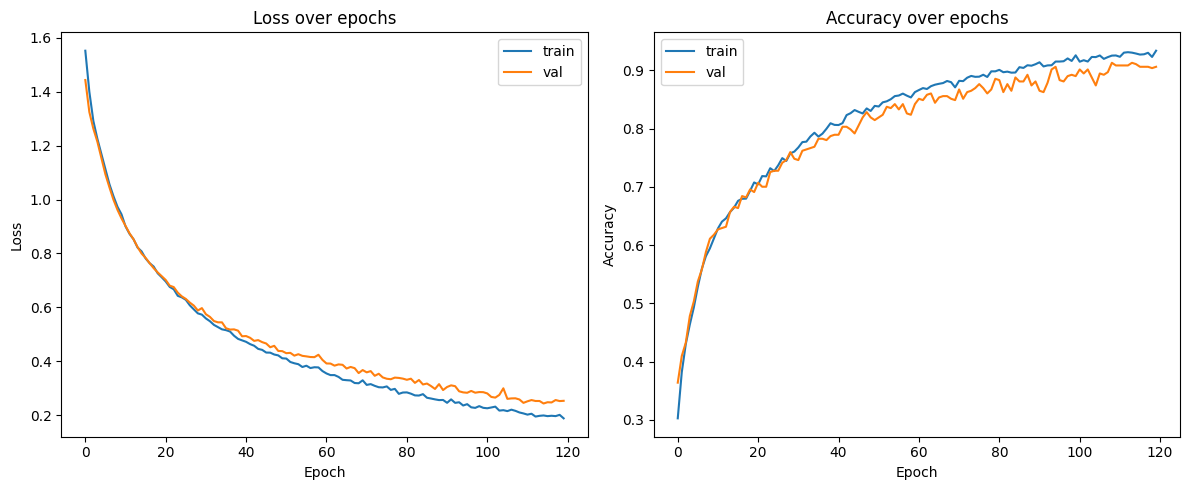

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Evaluate model

In [15]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

y_pred_probs = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

overall_acc = accuracy_score(y_test_seq, y_pred)
print("Overall Test Accuracy:", overall_acc)

# Confusion matrix for all classes (force full label range)
labels_full = np.arange(NUM_CLASSES)
cm = confusion_matrix(y_test_seq, y_pred, labels=labels_full)

# per-class accuracy (handle zero samples)
denom = cm.sum(axis=1)
per_class_acc = np.divide(cm.diagonal(), denom,
                          out=np.zeros_like(cm.diagonal(), dtype=float),
                          where=denom!=0)

class_names = label_encoder.inverse_transform(labels_full)

for name, acc, n in zip(class_names, per_class_acc, denom):
    print(f"{name:20s} : {acc:.3f}  (n_test={int(n)})")

print("\nClassification Report (only shows classes present in y_test):")
print(classification_report(y_test_seq, y_pred, labels=np.unique(y_test_seq),
                            target_names=label_encoder.inverse_transform(np.unique(y_test_seq))))


137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step
Overall Test Accuracy: 0.9147375658950263
air                  : 0.911  (n_test=831)
basil                : 0.869  (n_test=887)
cinnamon             : 0.925  (n_test=876)
oregano              : 0.954  (n_test=861)
rosemary             : 0.916  (n_test=908)

Classification Report (only shows classes present in y_test):
              precision    recall  f1-score   support

         air       0.96      0.91      0.94       831
       basil       0.90      0.87      0.88       887
    cinnamon       0.87      0.92      0.90       876
     oregano       0.96      0.95      0.96       861
    rosemary       0.89      0.92      0.90       908

    accuracy                           0.91      4363
   macro avg       0.92      0.91      0.92      4363
weighted avg       0.92      0.91      0.91      4363



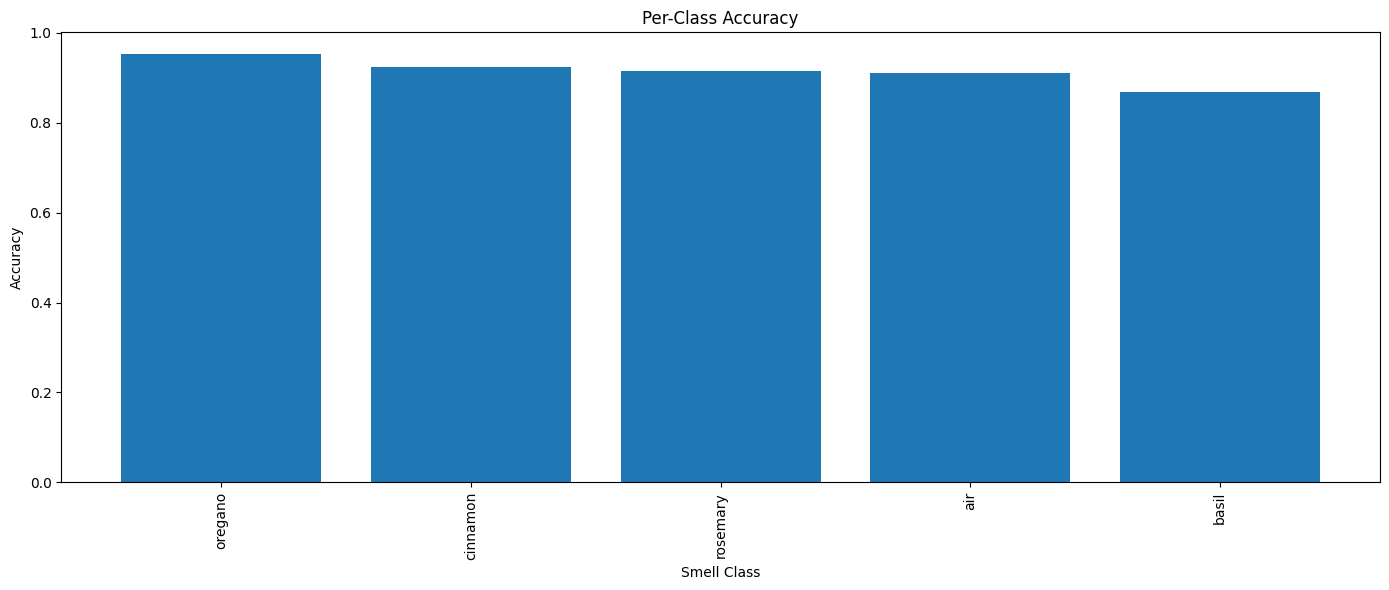

In [16]:
import matplotlib.pyplot as plt

sorted_idx = np.argsort(per_class_acc)[::-1]
sorted_acc = per_class_acc[sorted_idx]
sorted_names = class_names[sorted_idx]

plt.figure(figsize=(14,6))
plt.bar(sorted_names, sorted_acc)
plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.xlabel("Smell Class")
plt.title("Per-Class Accuracy")
plt.tight_layout()
plt.show()

In [17]:
model.save("model.keras")

## Convert to LiteRT model

In [18]:
import tensorflow as tf
import os

converter = tf.lite.TFLiteConverter.from_keras_model(model)
# Removed converter.optimizations = [tf.lite.Optimize.DEFAULT] to disable quantization for debugging

converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Apply the suggested fix for LSTM models
#converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
#converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

with open('model.tflite', 'wb') as f:
  f.write(tflite_model)

basic_model_size = os.path.getsize("model.tflite")
print("Model is %d bytes" % basic_model_size)


INFO:tensorflow:Assets written to: C:\Users\james\AppData\Local\Temp\tmp3mur83k4\assets


INFO:tensorflow:Assets written to: C:\Users\james\AppData\Local\Temp\tmp3mur83k4\assets


Saved artifact at 'C:\Users\james\AppData\Local\Temp\tmp3mur83k4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3, 5), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  1869734263504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1869738494480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1869738498320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1869738494864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1869738495632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1869738493136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1869738494096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1869738493712: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model is 12480 bytes


In [19]:
from ai_edge_litert.compiled_model import CompiledModel
import numpy as np # Import numpy as it's used in the loop

model_lite = CompiledModel.from_file("model.tflite")

signature_index = 0

input_buffers = model_lite.create_input_buffers(signature_index)
output_buffers = model_lite.create_output_buffers(signature_index)

n_correct = 0

for i in range(len(X_test_seq)):
    input_data = np.float32(X_test_seq[i])
    input_buffers[0].write(input_data)

    model_lite.run_by_index(signature_index, input_buffers, output_buffers)
    output_array = output_buffers[0].read(NUM_CLASSES, np.float32)

    pred_class = int(np.argmax(output_array))
    true_class = int(y_test_seq[i])

    if pred_class == true_class:
        n_correct += 1

print("LiteRT accuracy:", n_correct / len(X_test_seq))

LiteRT accuracy: 0.9117579647031859


In [20]:
# Scaler parameters

means = scaler.mean_
stds = scaler.scale_

print("Means:", means)
print("Stds:", stds)

Means: [ 2.81567362e+01  1.06429269e+03  4.35529353e+01  3.19133787e+06
 -3.05737820e+05]
Stds: [2.56571947e+00 3.89290844e+01 7.33259542e+00 1.97826805e+06
 3.23751232e+05]


In [21]:
import pandas as pd

scaler_info = pd.DataFrame({
    "feature": FEATURE_COLS_EXTENDED,
    "mean": scaler.mean_,
    "std": scaler.scale_
})

scaler_info.to_csv("scaler_info.csv", index=False)
print("Saved scaler info to scaler_info.csv")

Saved scaler info to scaler_info.csv
